In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#the main lib here is the statmodel
from scipy.io.arff import loadarff
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [6]:
import arff
import pandas as pd

# Open and decode the ARFF file using liac-arff
with open('dataset.arff', 'r', encoding='utf-8') as f:
    dataset = arff.load(f)

# Extract attributes and data points
column_names = [attr[0] for attr in dataset['attributes']]
df = pd.DataFrame(dataset['data'], columns=column_names)

# Display your successful DataFrame
df.head()



,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [9]:
df.groupby('station')['PM2.5'].mean()

station
Aotizhongxin     82.773611
Changping        71.099743
Dingling         65.989497
Dongsi           86.194297
Guanyuan         82.933372
Gucheng          83.852089
Huairou          69.626367
Nongzhanguan     84.838483
Shunyi           79.491602
Tiantan          82.164911
Wanliu           83.374716
Wanshouxigong    85.024136
Name: PM2.5, dtype: float64

## 1. Data Cleaning and Pre-processing

First things first, our data includes reading from across several weather stations, the next step would be to focus our attention on one of the stations, preferably one with the most training examples and less missingness

In [28]:
df.groupby("station")["PM2.5"].apply(lambda x: x.isna().sum()).sort_values()

station
Wanliu           382
Guanyuan         616
Nongzhanguan     628
Gucheng          646
Tiantan          677
Wanshouxigong    696
Dongsi           750
Changping        774
Dingling         779
Shunyi           913
Aotizhongxin     925
Huairou          953
Name: PM2.5, dtype: int64

### Focus the data to a station

In [29]:
new_df=df[df['station'] == 'Wanliu'].copy()

#### Create a Time-Series Index...
Time series tools in pandas and statsmodels expect a `DatetimeIndex`. We combine the four timestamp columns into one.

In [30]:
new_df["datetime"] = pd.to_datetime(new_df[["year", "month", "day", "hour"]])
new_df.set_index("datetime", inplace=True)
new_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
2013-03-01 01:00:00,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2013-03-01 02:00:00,3,2013,3,1,2,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
2013-03-01 03:00:00,4,2013,3,1,3,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
2013-03-01 04:00:00,5,2013,3,1,4,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu


In [31]:
new_df = new_df.drop(columns=['No','year', 'month', 'day', 'hour', 'station'])

### Checking for missingness

In [32]:
new_df.isnull().sum()

PM2.5     382
PM10      284
SO2       575
NO2      1070
CO       1812
O3       2107
TEMP       20
PRES       20
DEWP       20
RAIN       20
wd        123
WSPM       14
dtype: int64

We have 925 values missing in the PM2.5 feature. Go to method would be to interpolate...

<Axes: title={'center': 'PM2.5 Levels Over Time'}, xlabel='datetime'>

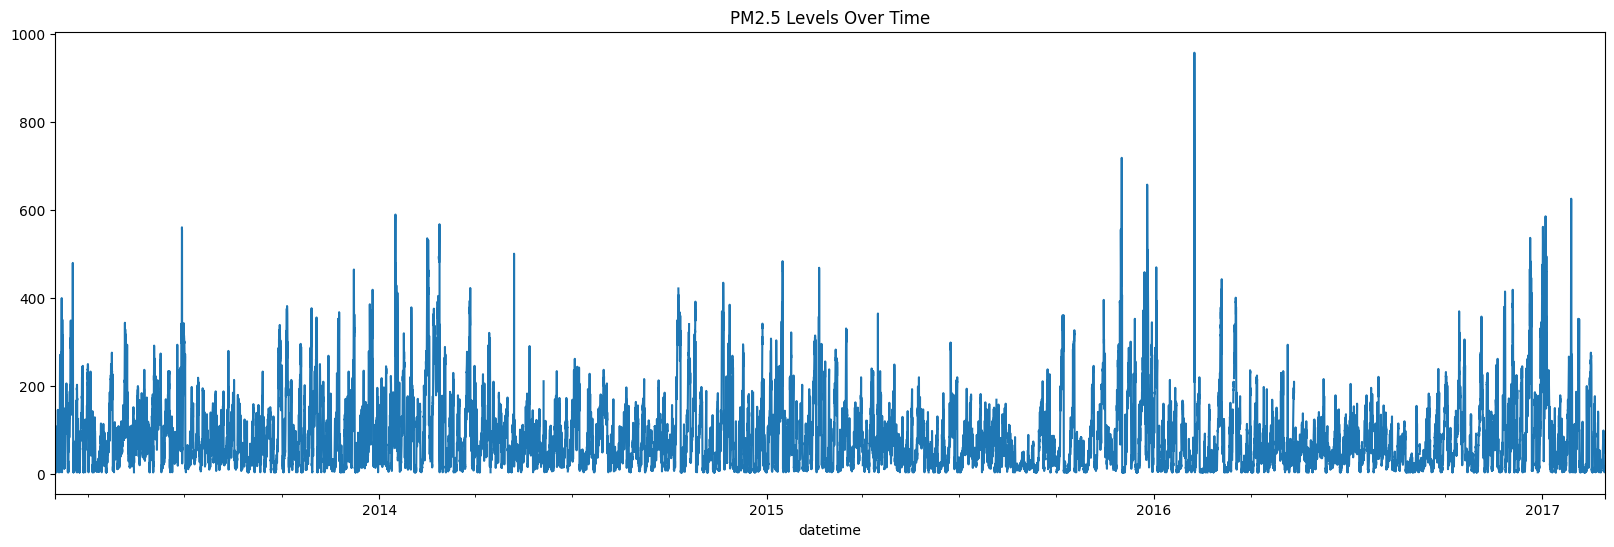

In [33]:
new_df['PM2.5'].plot(figsize=(20,6), title='PM2.5 Levels Over Time')

In [34]:
new_df['PM2.5'] = new_df['PM2.5'].interpolate(method='time', limit=24, limit_direction='both')

In [35]:
new_df.isnull().sum()

PM2.5       0
PM10      284
SO2       575
NO2      1070
CO       1812
O3       2107
TEMP       20
PRES       20
DEWP       20
RAIN       20
wd        123
WSPM       14
dtype: int64

# Exploratory Data Analysis

Next we need to choose the appropriate temporal resolution - do we want to predict hourly readings or daily readings?

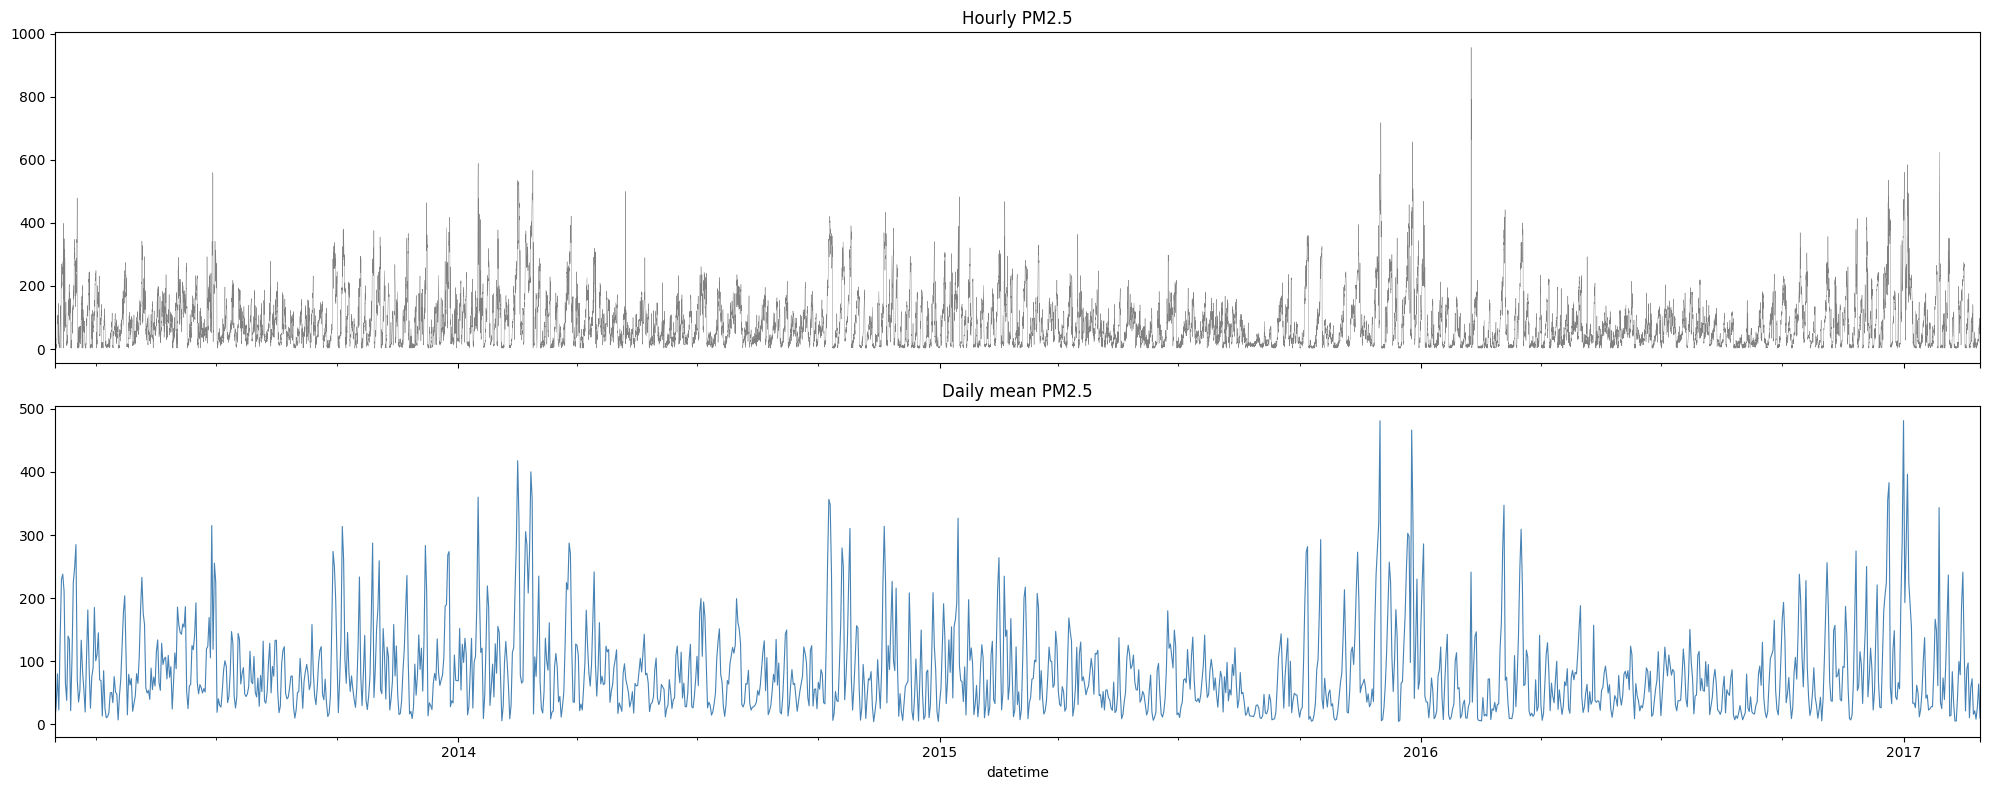

In [41]:
fig,axes= plt.subplots(2,1, figsize=(20, 8),sharex=True)

new_df["PM2.5"].plot(ax=axes[0], lw=0.3, color="grey", title="Hourly PM2.5")
new_df["PM2.5"].resample("D").mean().plot(ax=axes[1], lw=0.8, color="steelblue", title="Daily mean PM2.5")

plt.tight_layout()
plt.show()


Best resolution: Hourly pollution data is very noisy,better to model on a daily resolution.

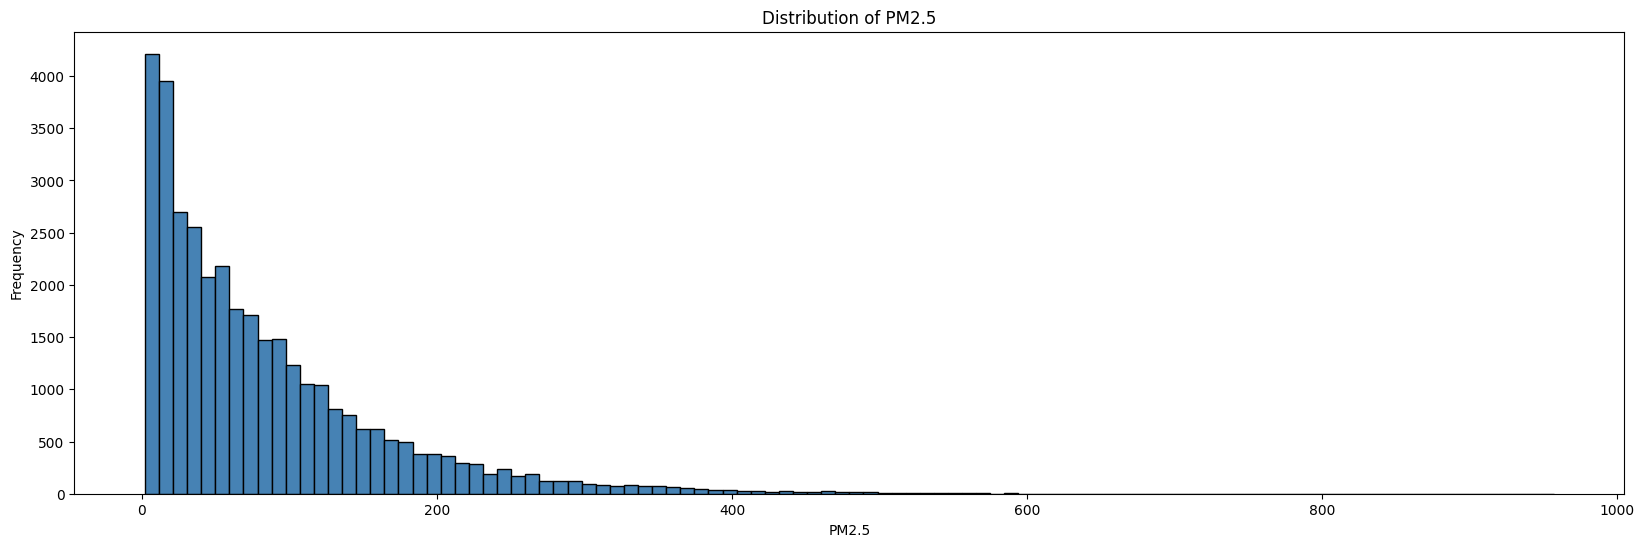

In [42]:
fig= plt.figure(figsize=(20, 6))

plt.hist(new_df["PM2.5"], bins=100, color="steelblue", edgecolor="black")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5")
plt.show()

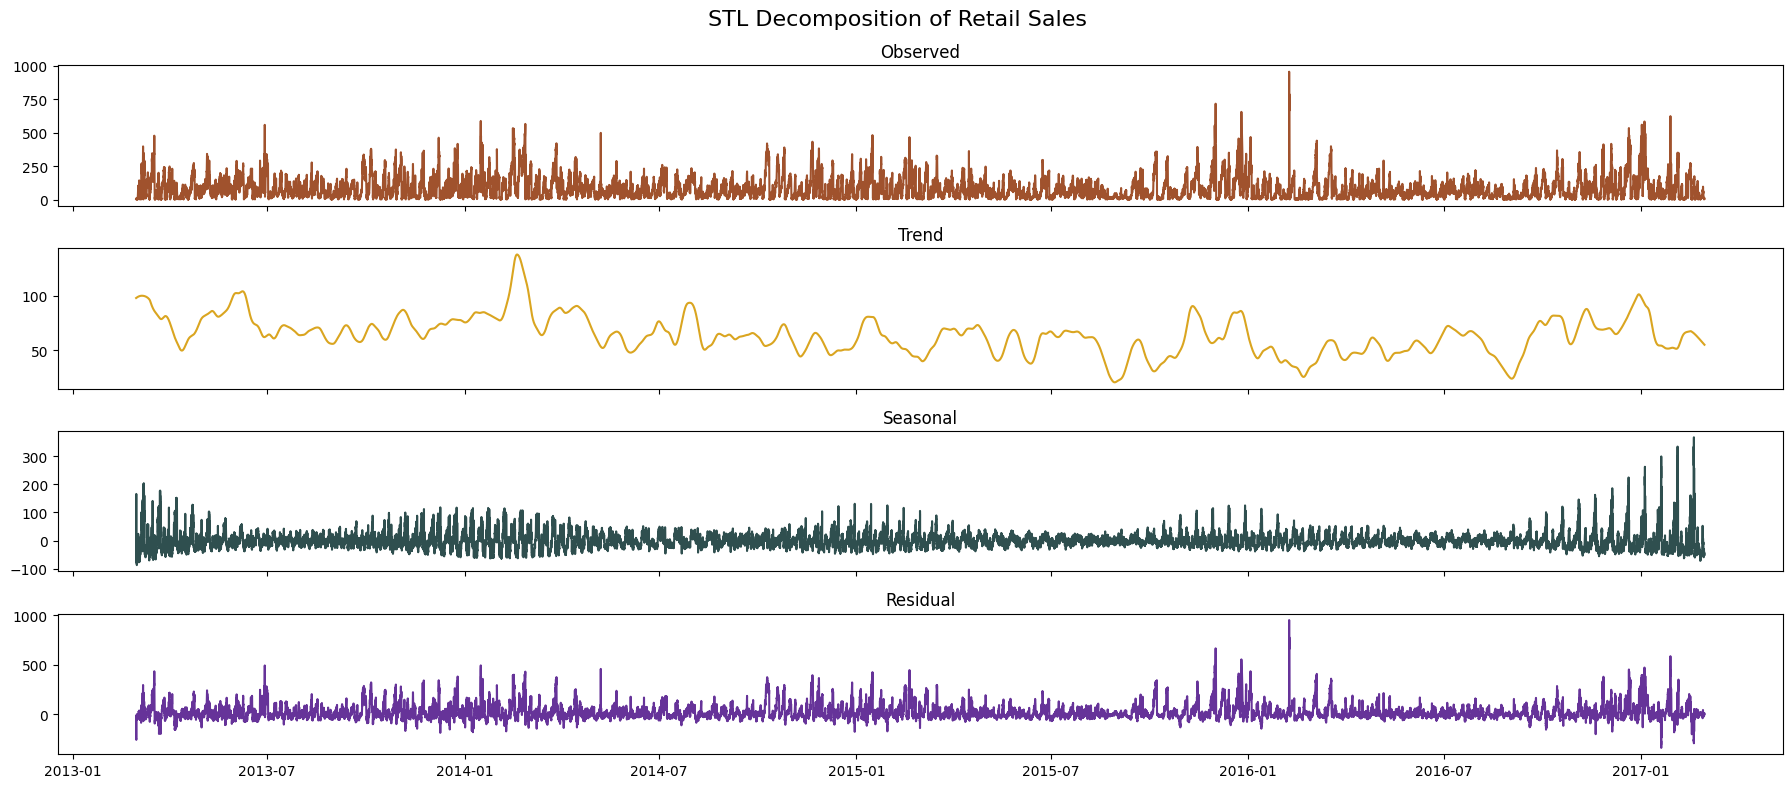

In [45]:
# Apply STL decomposition
stl = STL(new_df['PM2.5'], seasonal=13,period=365, robust=True)
result = stl.fit()

# Plot and save STL components
fig, axs = plt.subplots(4, 1, figsize=(18, 8), sharex=True)

axs[0].plot(result.observed, color='sienna')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='goldenrod')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkslategrey')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='rebeccapurple')
axs[3].set_title('Residual')

plt.suptitle('STL Decomposition of PM2.5', fontsize=16)
plt.tight_layout()
plt.show()

In [46]:
result = adfuller(new_df['PM2.5'])


print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

# Decision based on p-value
if result[1] <= 0.05:
    print("Reject the null hypothesis (H0). The time series is stationary.")
else:
    print("The p values is more than 0.05,Fail to reject the null hypothesis (H0). The time series is non-stationary.")

ADF Statistic: -18.92662914556093
p-value: 0.0
Critical Values:
	1%: -3.43053678680168
	5%: -2.861622555151452
	10%: -2.5668139415123283
Reject the null hypothesis (H0). The time series is stationary.
